# Buehler et al. (2019) §3.2 — Table 3.1 and Figure 3.1
Compares discretized BS hedge (theoretical) vs NN hedge for ES_α loss.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

from src.hedging.hedge_network import HedgeNet
from src.gbm_simulator import GBMParams, simulate

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

In [2]:
# Parameters
S0, K, sigma, mu = 100.0, 100.0, 0.2, 0.0
N, dt = 30, 1/365
T = N * dt
ALPHAS = [0.5, 0.75, 0.95, 0.99]

# Test paths (fresh seed)
params = GBMParams(S0=S0, mu=mu, sigma=sigma, T=T, N=N, M=100_000)
paths  = simulate(params, seed=999)
print('Test paths:', paths.shape)

Test paths: torch.Size([100000, 31])


In [3]:
def bs_delta(S, tau, K, sigma):
    """BS delta for a European call."""
    if tau <= 1e-9:
        return (S > K).float()
    d1 = (torch.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * tau**0.5)
    return torch.distributions.Normal(0, 1).cdf(d1)

def compute_pl(holding, paths, p0):
    """PL = p0 + PnL - C_T  per path."""
    PnL = (holding * (paths[:, 1:] - paths[:, :-1])).sum(dim=1)
    C_T = torch.clamp(paths[:, -1] - K, min=0.0)
    return p0 + PnL - C_T

def pl_stats(pl, label):
    pl = pl.numpy()
    var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
    quantiles  = [np.quantile(pl, 1 - v) for v in var_levels]
    print(f"{label:<18}  mean={pl.mean():.4f}  "
          + "  ".join(f"VaR{int(v*100)}={q:.4f}" for v, q in zip(var_levels, quantiles)))
    return pl.mean(), quantiles

In [4]:
# ---- Discretized BS hedge ----
bs_holding = torch.zeros(paths.shape[0], N)
for t in range(N):
    tau = T - t * dt
    bs_holding[:, t] = bs_delta(paths[:, t], tau, K, sigma)

# BS p0 = Black-Scholes call price at t=0
d1_0  = (np.log(S0/K) + 0.5*sigma**2*T) / (sigma*T**0.5)
d2_0  = d1_0 - sigma*T**0.5
p0_bs = S0*norm.cdf(d1_0) - K*norm.cdf(d2_0)
print(f'BS price: {p0_bs:.4f}')

pl_bs   = compute_pl(bs_holding, paths, p0_bs)
mean_bs, q_bs = pl_stats(pl_bs, 'Theoretical (BS)')

BS price: 2.2872
Theoretical (BS)    mean=0.0004  VaR99=-0.9961  VaR95=-0.5927  VaR90=-0.4270  VaR80=-0.2587  VaR50=0.0049


In [5]:
# ---- NN hedges for each α ----
# NOTE: p0 from CVaR training is the learned VaR threshold, NOT the option price.
# Economic P&L uses the BS price as the premium received for BOTH hedges (fair comparison).
nn_pls = {}

for alpha in ALPHAS:
    tag = str(alpha).replace('.', '')
    network = HedgeNet(N=N, width=20)
    network.load_state_dict(torch.load(RESULTS_DIR / f'buehler_ES{tag}_network.pt',
                                       weights_only=True))
    network.eval()

    with torch.no_grad():
        x       = torch.log(paths[:, :-1]).unsqueeze(-1)
        holding = network(x)

    pl = compute_pl(holding, paths, p0_bs)   # always BS price as premium
    nn_pls[alpha] = pl
    pl_stats(pl, f'ES_{alpha} NN')

ES_0.5 NN           mean=0.0008  VaR99=-2.6405  VaR95=-1.6178  VaR90=-1.1570  VaR80=-0.6631  VaR50=0.1052


ES_0.75 NN          mean=0.0015  VaR99=-0.9923  VaR95=-0.7201  VaR90=-0.5819  VaR80=-0.4126  VaR50=-0.0270


ES_0.95 NN          mean=-0.0062  VaR99=-4.2820  VaR95=-3.0425  VaR90=-2.4006  VaR80=-1.6426  VaR50=-0.2373


ES_0.99 NN          mean=-0.0140  VaR99=-6.6552  VaR95=-4.7035  VaR90=-3.6749  VaR80=-2.3947  VaR50=0.0037


In [6]:
# ---- Table 3.1 ----
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Model':<18} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))

def row(label, pl):
    pl = pl.numpy()
    qs = [np.quantile(pl, 1 - v) for v in var_levels]
    return f"{label:<18} {pl.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs)

print(row('Theoretical', pl_bs))
for alpha in ALPHAS:
    print(row(f'ES_{alpha} NN', nn_pls[alpha]))

Model                  Mean     VaR99     VaR95     VaR90     VaR80     VaR50
-----------------------------------------------------------------------------
Theoretical          0.0004   -0.9961   -0.5927   -0.4270   -0.2587    0.0049
ES_0.5 NN            0.0008   -2.6405   -1.6178   -1.1570   -0.6631    0.1052
ES_0.75 NN           0.0015   -0.9923   -0.7201   -0.5819   -0.4126   -0.0270
ES_0.95 NN          -0.0062   -4.2820   -3.0425   -2.4006   -1.6426   -0.2373
ES_0.99 NN          -0.0140   -6.6552   -4.7035   -3.6749   -2.3947    0.0037


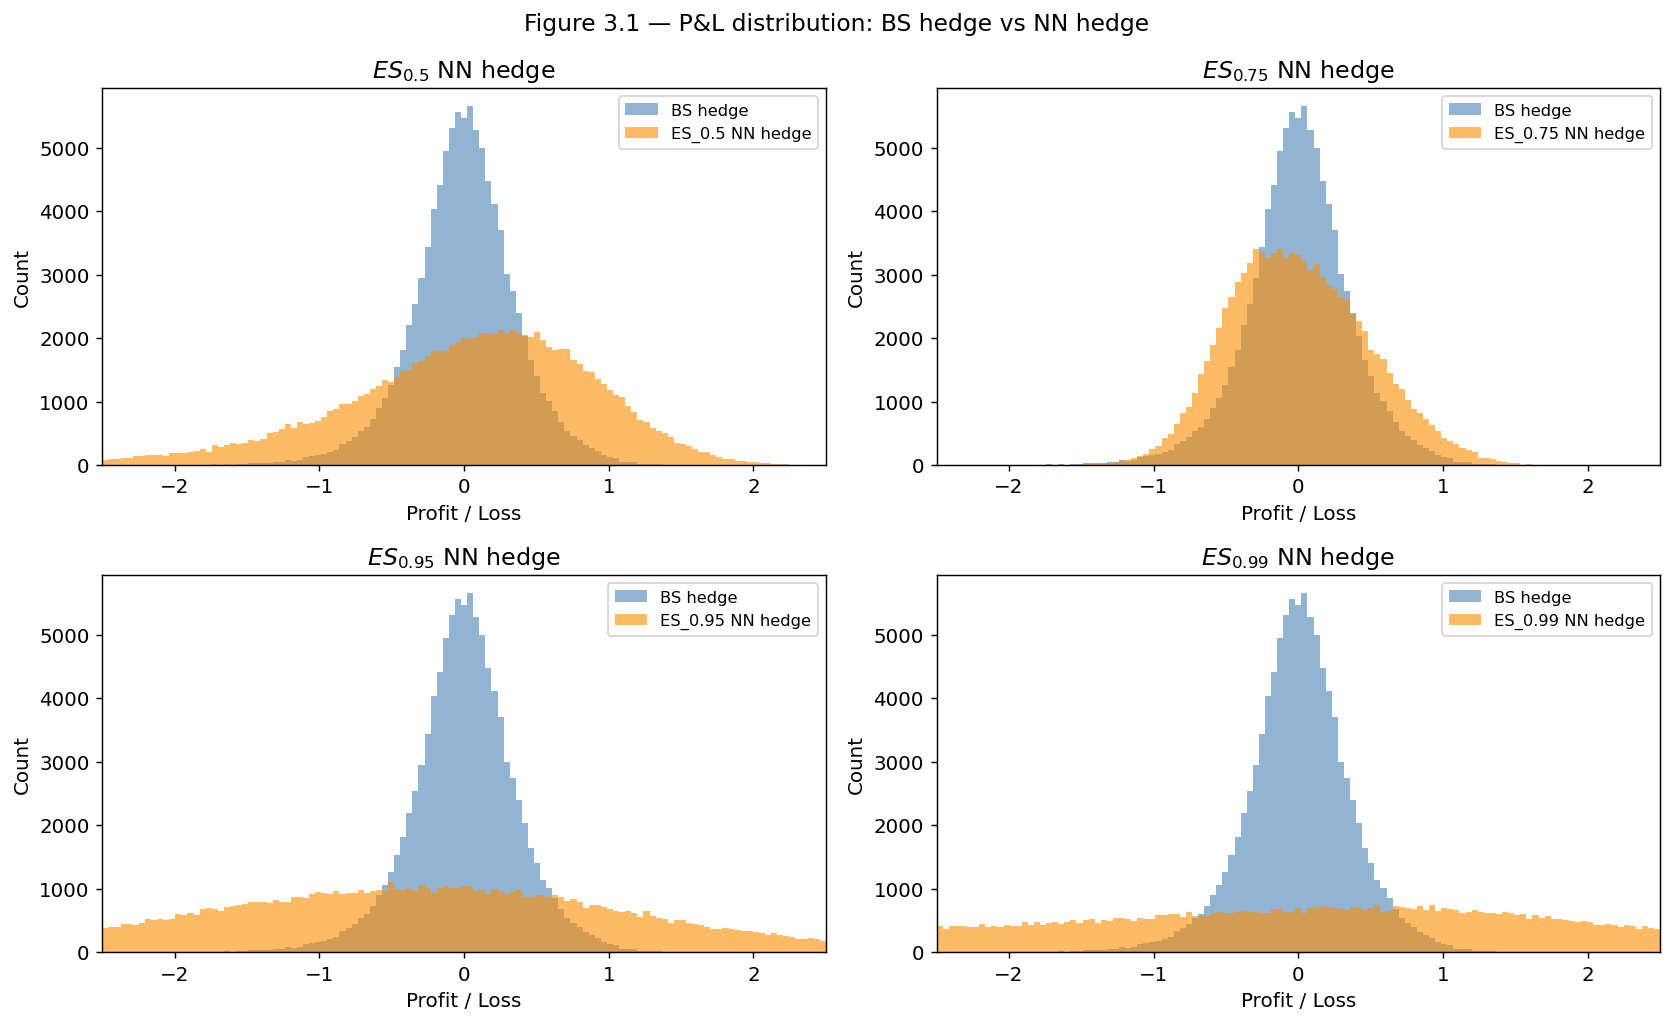

In [7]:
# ---- Figure 3.1 ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, alpha in zip(axes.flat, ALPHAS):
    pl_nn  = nn_pls[alpha].numpy()
    pl_bs_ = pl_bs.numpy()
    xlim   = (-2.5, 2.5)
    bins   = np.linspace(*xlim, 120)

    ax.hist(pl_bs_,  bins=bins, alpha=0.6, color='steelblue', label='BS hedge',     density=False)
    ax.hist(pl_nn,   bins=bins, alpha=0.6, color='darkorange', label=f'ES_{alpha} NN hedge', density=False)
    ax.set_xlim(xlim)
    ax.set_xlabel('Profit / Loss')
    ax.set_ylabel('Count')
    ax.set_title(f'$ES_{{{alpha}}}$ NN hedge')
    ax.legend(fontsize=9)

fig.suptitle('Figure 3.1 — P&L distribution: BS hedge vs NN hedge', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'buehler_figure31.png', bbox_inches='tight')
plt.show()